In [307]:
import pandas as pd 
from scipy import fftpack
import numpy as np
import matplotlib.pyplot as plt
from vmdpy import VMD
from scipy.io import loadmat

In [308]:

file_path='../../数据集/CRWU/12k Drive End Bearing Fault Data/Inner Race/0007/IR007_0.mat'
data = loadmat(file_path)
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Jan 31 13:49:59 2000',
 '__version__': '1.0',
 '__globals__': [],
 'X105_DE_time': array([[-0.08300435],
        [-0.19573433],
        [ 0.23341928],
        ...,
        [-0.31642363],
        [-0.06367457],
        [ 0.26736822]]),
 'X105_FE_time': array([[-0.40207455],
        [-0.00472545],
        [-0.10663091],
        ...,
        [ 0.31598909],
        [ 0.35091636],
        [ 0.03307818]]),
 'X105_BA_time': array([[ 0.06466148],
        [-0.02309626],
        [-0.08852226],
        ...,
        [ 0.09648926],
        [ 0.08405591],
        [-0.02015893]]),
 'X105RPM': array([[1797]], dtype=uint16)}

In [309]:
data=data['X105_DE_time'].flatten()

In [310]:
f=data[10000:10000+4096]
len(f)

4096

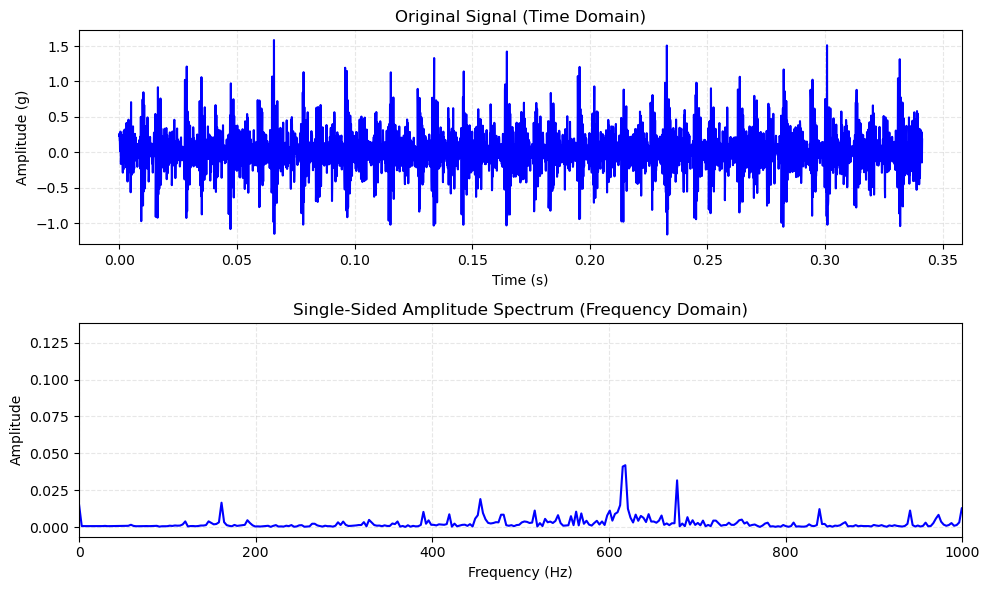

In [311]:
# 2. 时域向量
Fs=12000
L = len(f)
t = np.arange(L) / Fs

# 3. 频域分析 (FFT)
# 计算 FFT 并取单边谱
P2 = np.abs(np.fft.fft(f)) / L
P1 = P2[:L//2]
P1[1:] = 2 * P1[1:]  # 除直流分量外，幅值翻倍
frequ = np.linspace(0, Fs/2, L//2)

# 4. 绘图
plt.figure(figsize=(10, 6))

# 时域图
plt.subplot(2, 1, 1)
plt.plot(t, f, 'b')
plt.title('Original Signal (Time Domain)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (g)')
plt.grid(True, linestyle='--', alpha=0.3)

# 频域图
plt.subplot(2, 1, 2)
plt.plot(frequ, P1, 'b')
plt.title('Single-Sided Amplitude Spectrum (Frequency Domain)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(0, 1000)  # 可选：限制显示频率范围，看清低频特征

plt.tight_layout()
plt.show()

In [312]:
alpha = 5000;     
tau = 0;            
K = 4;            
DC = 0;             
init = 1;           
tol = 1e-7;

In [313]:
u, u_hat, omega = VMD(f, alpha, tau, K, DC, init, tol)



In [314]:
final_omegas = omega[-1, :] 
sort_index = np.argsort(final_omegas)
sort_index 

array([0, 1, 2, 3])

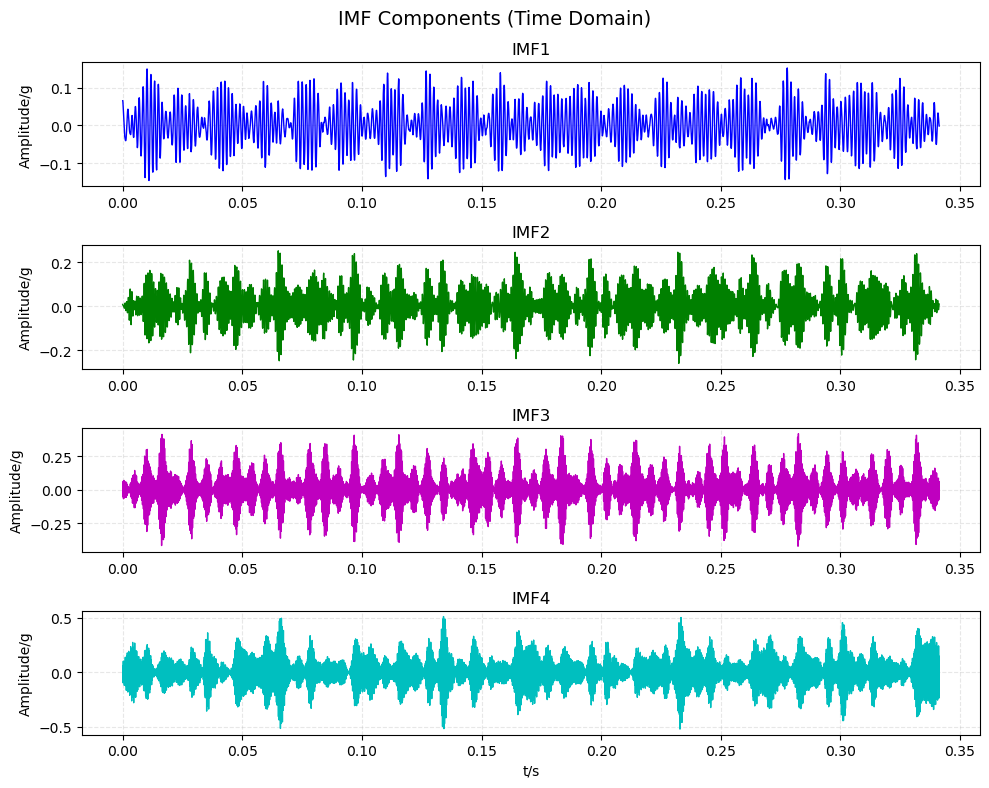

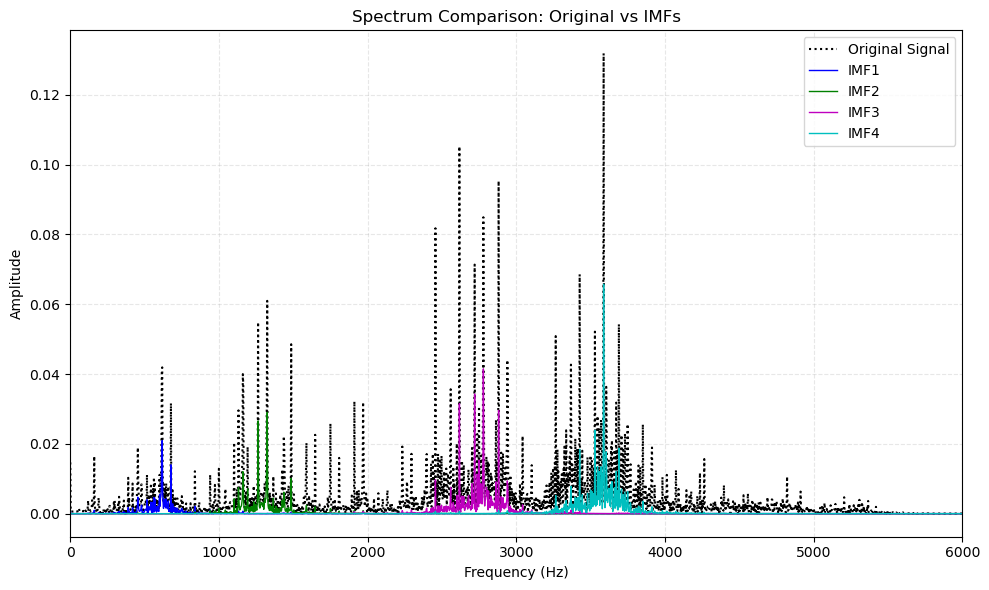

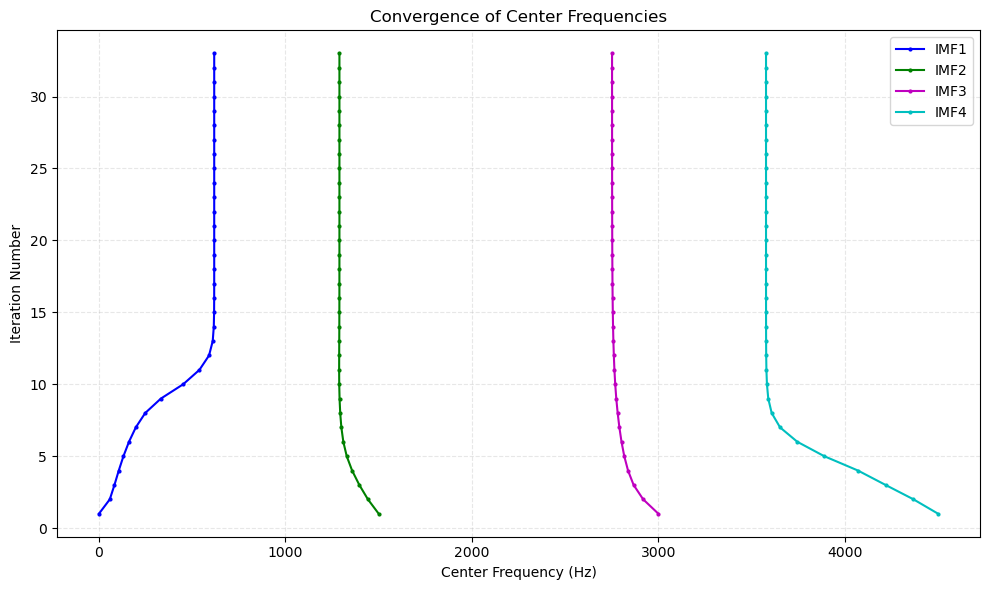

In [315]:
import numpy as np
import matplotlib.pyplot as plt

final_omegas = omega[-1, :] 
sort_index = np.argsort(final_omegas)

# 重排数据
omega = omega[:, sort_index]
u_hat = u_hat[:, sort_index]      # 注意：u_hat 通常是 (L, K)，需确认维度
u = u[sort_index, :]              # u 通常是 (K, L)

linestyles = ['b', 'g', 'm', 'c', 'r', 'k']
labels = [f'IMF{k+1}' for k in range(K)]

# ==========================================
# 1. IMF 时域分析 (Time Domain)
# ==========================================
plt.figure(figsize=(10, 8))
for k in range(K):
    plt.subplot(K, 1, k+1)
    plt.plot(t, u[k, :], linestyles[k % len(linestyles)], linewidth=1)
    plt.ylabel('Amplitude/g')
    plt.title(f'{labels[k]}')
    plt.grid(True, linestyle='--', alpha=0.3)
    # 最后一个子图加 xlabel
    if k == K - 1:
        plt.xlabel('t/s')
plt.suptitle('IMF Components (Time Domain)', fontsize=14)
plt.tight_layout()

# ==========================================
# 2. IMF 频域分析 (Frequency Domain)
# ==========================================
plt.figure(figsize=(10, 6))
# 绘制原始信号频谱 (黑色虚线)
plt.plot(frequ, P1, 'k:', label='Original Signal', linewidth=1.5)

# 绘制各 IMF 频谱
# 注意：MATLAB 代码中 abs(u_hat(L/2+1:end,k))/L 对应的是单边谱的后半段映射
# 假设 u_hat 是双边谱，我们需要取正频率部分并归一化
for k in range(K):
    # 提取正频率部分 (假设 u_hat 第一维是频率点，从0到Fs)
    # MATLAB: L/2+1:end 对应 Python: L//2 : 
    spectrum = np.abs(u_hat[L//2:, k]) / L 
    # 确保长度与 frequ 一致 (有时 FFT 点数会有细微差别，这里做截断或填充)
    length_match = min(len(spectrum), len(frequ))
    plt.plot(frequ[:length_match], spectrum[:length_match], 
             linestyles[k % len(linestyles)], label=labels[k], linewidth=1)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Spectrum Comparison: Original vs IMFs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(0, 6000) # 可根据需要调整显示范围
plt.tight_layout()

# ==========================================
# 3. 中心频率迭代收敛过程 (Convergence)
# ==========================================
plt.figure(figsize=(10, 6))
n_iter = omega.shape[0] # 迭代次数
y_axis = np.arange(1, n_iter + 1) # Y轴为迭代次数 (1 到 N)

for k in range(K):
    freq_vals = omega[:, k] * Fs 
    plt.plot(freq_vals, y_axis, linestyles[k % len(linestyles)], 
             marker='.', markersize=4, label=labels[k])

plt.xlabel('Center Frequency (Hz)')
plt.ylabel('Iteration Number')
plt.title('Convergence of Center Frequencies')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
# 反转Y轴，让第1次迭代在最上面 (可选，看个人习惯，MATLAB默认是下小上大)
# plt.gca().invert_yaxis() 
plt.tight_layout()

plt.show()

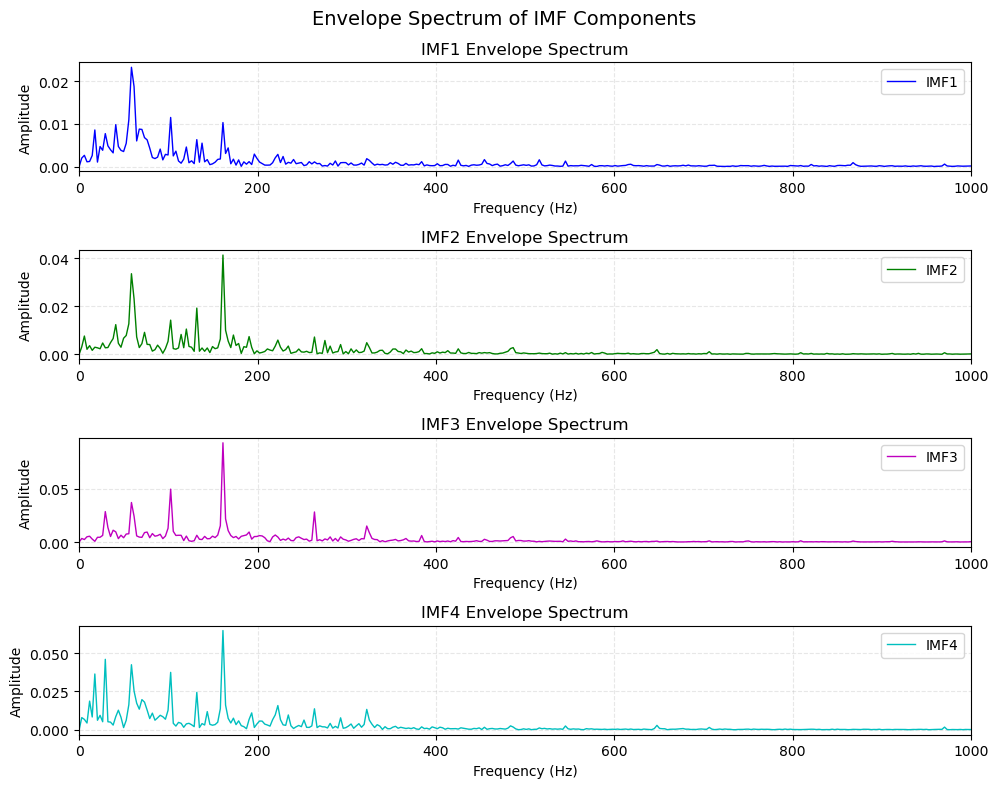

In [316]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# 假设变量已存在:
# u: IMF 分量矩阵 (K, L) - 注意：MATLAB 代码中先转置了，说明它期望列是时间序列
# K: 分量个数
# L: 信号长度
# Fs: 采样率
# frequ: 频率向量 (对应 0 到 Fs/2)
# linestyles: 颜色列表 ['b', 'g', ...]

# ==========================================
# 包络谱分析 (Envelope Spectrum Analysis)
# ==========================================

# 1. 希尔伯特变换提取包络
# 注意：scipy.signal.hilbert 默认沿最后一个轴变换。
# 如果 u 是 (K, L)，我们需要对每一行（时间轴）做变换。
# MATLAB: hilbert(u') -> u' 是 (L, K)，对列做变换。
# Python: 直接对 axis=1 (列方向) 做变换即可，无需转置，只要维度对齐。
analytic_signal = hilbert(u, axis=1) 
envelope = np.abs(analytic_signal)

# 2. 去直流分量 (减去均值)
# MATLAB: mean(u_h_bao_luo) 默认按列求平均 (dim=1)，结果是 (1, K)
# Python: mean(axis=1) 得到 (K,)，需要 reshape 为 (K, 1) 以便广播相减
mean_envelope = np.mean(envelope, axis=1, keepdims=True) 
envelope_detrended = envelope - mean_envelope

# 3. FFT 频谱分析
# 对去直流后的包络做 FFT
fft_envelope = np.fft.fft(envelope_detrended, axis=1)

# 取单边谱 (只取前 L/2 个点)
L_half = L // 2
P2_env = np.abs(fft_envelope[:, :L_half]) / L  # 归一化

# 幅值修正 (乘以2)，注意：第0个点(DC)和第L/2个点(Nyquist)不乘
# Python 索引: 0 是 DC, 1 到 L/2-1 是正频率
P1_env = P2_env.copy()
P1_env[:, 1:L_half-1] = 2 * P1_env[:, 1:L_half-1]

# 此时 P1_env 的形状是 (K, L/2)
# 对应的频率轴应该是 frequ (假设 frequ 长度也是 L/2)

# ==========================================
# 绘图
# ==========================================
plt.figure(figsize=(10, 2 * K))

for k in range(K):
    plt.subplot(K, 1, k+1)
    
    # 提取当前分量的包络谱数据
    # P1_env[k, :] 对应 MATLAB 的 P1_VMD_bao_luo(:, k) (注意 MATLAB 这里是列向量)
    # 我们的 P1_env 是 (K, L/2)，所以取行
    spectrum_data = P1_env[k, :]
    
    # 确保频率轴和数据长度一致
    freq_axis = frequ[:len(spectrum_data)]
    
    plt.plot(freq_axis, spectrum_data, linestyles[k % len(linestyles)], linewidth=1)
    
    plt.title(f'IMF{k+1} Envelope Spectrum')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.legend([f'IMF{k+1}'])
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # 关键：限制 X 轴范围为 0-1000 Hz (对应 MATLAB 的 axis([0 1000 ...]))
    # 同时自动调整 Y 轴范围以适配数据
    plt.xlim(0, 1000)
    
    # 可选：如果数据太小，可以设置 ylim 自动适应，或者像 MATLAB 一样手动设
    # plt.ylim(min(spectrum_data), max(spectrum_data)) 

plt.suptitle('Envelope Spectrum of IMF Components', fontsize=14)
plt.tight_layout()
plt.show()